# NumCompute-Stream — Streaming ML Demo

This notebook demonstrates the **NumCompute-Stream** framework: a NumPy-only
(no scikit-learn, no pandas) toolkit for **streaming / incremental** tree-based
classification.

Through the code segments I am trying to:
1. Load a CSV stream with the custom `io` layer.
2. Build a `Pipeline` of streaming transformers + a model.
3. Train **incrementally** chunk-by-chunk with `partial_fit`, scoring each
   chunk *before* training on it (prequential evaluation).
4. Compare a single Hoeffding tree against an online Random Forest.
5. Visualise the logged metrics with the `visualise` module.


In [10]:
import sys, os
# the package lives one directory up from demo/; make it importable
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from numcompute_stream import (
    load_csv, iter_chunks,
    Pipeline, Imputer, StandardScaler,
    DecisionTreeClassifier, RandomForestClassifier,
    StreamTrainer, visualise,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Load the stream

`load_csv` is implemented purely on top of the stdlib `csv` module + NumPy.
Missing cells are returned as `NaN`

In [11]:
DATA_PATH = '../data/stream_data.csv'   # Here we are pointing to out dataset
CHUNK_SIZE = 300

X, y, meta = load_csv(DATA_PATH, target=-1, has_header=True,
                      categorical_target=True)
classes = np.unique(y)
print('X shape :', X.shape)
print('classes :', meta['classes'])
print('missing cells:', int(np.isnan(X).sum()))

X shape : (6000, 7)
classes : ['0', '1', '2']
missing cells: 805


## 2. Building a streaming pipeline

Every step supports `partial_fit`. The `Imputer` learns running column means,
the `StandardScaler` keeps Welford running mean/variance, and the model grows
online. The pipeline transforms forward and trains the final estimator in one
`partial_fit` call.

In [12]:
def make_pipeline(model):
    return Pipeline([
        ('impute', Imputer('mean')),
        ('scale', StandardScaler()),
        ('model', model),
    ])

tree_params = dict(max_depth=10, min_samples_split=60, delta=0.05)
models = {
    'Single tree': make_pipeline(DecisionTreeClassifier(**tree_params)),
    'Random forest': make_pipeline(
        RandomForestClassifier(n_estimators=12, max_features='sqrt',
                               tree_params=tree_params, random_state=0)),
}

## 3. Prequential training loop

`StreamTrainer` drives **test-then-train**: each chunk is scored with the model
as it stands, *then* used to update it. It logs per-chunk accuracy, cumulative
and rolling accuracy, fit time, and model memory footprint.

In [13]:
histories = {}
for name, pipe in models.items():
    trainer = StreamTrainer(pipe, prequential=True, rolling_window=200)
    # fresh chunk iterator per model so both see the identical stream order
    chunks = iter_chunks(X, y, chunk_size=CHUNK_SIZE, shuffle=False)
    trainer.run(chunks, classes=classes)
    histories[name] = trainer.history
    s = trainer.summary()
    print(f"{name:14s} cum_acc={s['final_cumulative_accuracy']:.3f}  "
          f"roll_acc={s['final_rolling_accuracy']:.3f}  "
          f"fit={s['total_fit_time_s']:.3f}s  "
          f"mem={s['final_memory_bytes']/1024:.1f}KB")

Single tree    cum_acc=0.876  roll_acc=0.950  fit=0.044s  mem=25.0KB
Random forest  cum_acc=0.954  roll_acc=0.970  fit=0.282s  mem=299.3KB


## 4. Visualise accuracy over the stream

`plot_metric_over_time` and `compare_models` come straight from the reusable
`visualise` module.

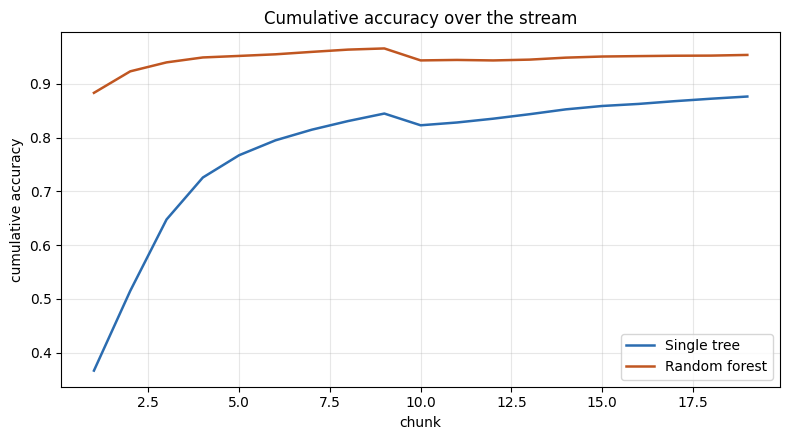

In [14]:
fig = visualise.compare_models(
    histories['Single tree']['cumulative_accuracy'],
    histories['Random forest']['cumulative_accuracy'],
    labels=('Single tree', 'Random forest'),
    title='Cumulative accuracy over the stream',
    ylabel='cumulative accuracy', show=True)
plt.show()

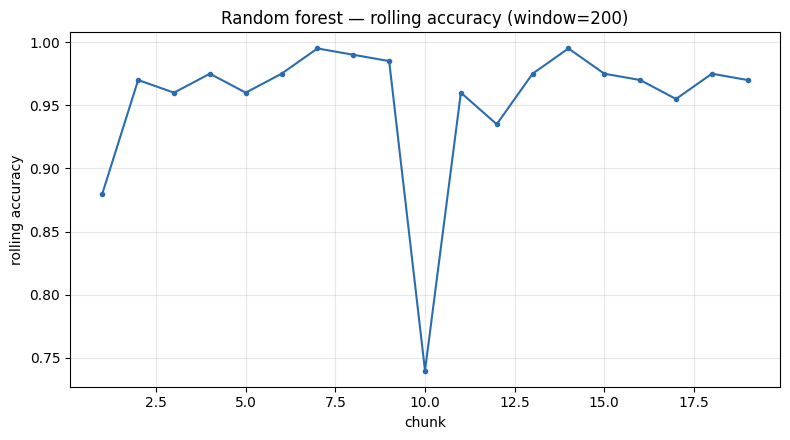

In [15]:
fig = visualise.plot_metric_over_time(
    histories['Random forest']['rolling_accuracy'],
    title='Random forest — rolling accuracy (window=200)',
    ylabel='rolling accuracy', show=True)
plt.show()

## 5. Predictions vs. ground truth on the latest chunk

Finally we inspect where the trained forest agrees / disagrees with the truth
on the most recent chunk of the stream.

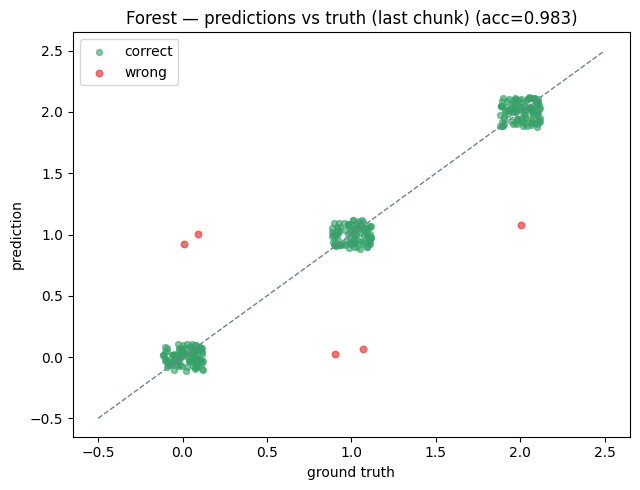

last-chunk accuracy: 0.9833333333333333


In [16]:
# grab the final chunk and predict with the trained forest pipeline
last_X, last_y = list(iter_chunks(X, y, chunk_size=CHUNK_SIZE,
                                  shuffle=False))[-1]
forest_pipe = models['Random forest']
pred = forest_pipe.predict(last_X)

fig = visualise.plot_predictions_vs_ground_truth(
    last_y, pred, title='Forest — predictions vs truth (last chunk)',
    show=True)
plt.show()
print('last-chunk accuracy:', float(np.mean(pred == last_y)))

## 6. Edge cases

The cells below verify that the framework handles four stress conditions that
commonly break streaming pipelines. Each should complete without raising and
produce sensible (non-NaN, non-crash) output.

* **All-NaN column** — one feature is missing for every row in a chunk.
* **Single-class chunk** — a chunk that contains only one label (e.g. a burst of class 0).
* **Zero-variance feature** — a constant column that would cause division-by-zero in a naive scaler.
* **Empty chunk** — `X.shape[0] == 0`, which can occur at stream boundaries.

In [17]:
# ── Edge case 1: all-NaN column ──────────────────────────────────────────────
rng_ec = np.random.default_rng(99)
X_nan = rng_ec.normal(size=(80, 4)).astype(float)
X_nan[:, 2] = np.nan          # feature 2 is entirely missing in this chunk
y_nan = rng_ec.integers(0, 2, size=80).astype(float)

pipe_ec = Pipeline([
    ('impute', Imputer('mean')),
    ('scale',  StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, min_samples_split=20)),
])
pipe_ec.partial_fit(X_nan, y_nan, classes=np.array([0.0, 1.0]))
pred_nan = pipe_ec.predict(X_nan)
assert not np.isnan(pred_nan).any(), 'predictions contain NaN after all-NaN column chunk'
print('Edge 1 — all-NaN column: OK  (predictions shape', pred_nan.shape, ')')

# ── Edge case 2: single-class chunk ──────────────────────────────────────────
X_single = rng_ec.normal(size=(60, 4))
y_single = np.zeros(60)        # only class 0 in this chunk

pipe_ec2 = Pipeline([
    ('impute', Imputer('mean')),
    ('scale',  StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, min_samples_split=20)),
])
pipe_ec2.partial_fit(X_single, y_single, classes=np.array([0.0, 1.0]))
# send a mixed chunk next — tree must not crash when it previously saw 1 class
X_mix = rng_ec.normal(size=(60, 4))
y_mix = rng_ec.integers(0, 2, size=60).astype(float)
pipe_ec2.partial_fit(X_mix, y_mix, classes=np.array([0.0, 1.0]))
print('Edge 2 — single-class chunk followed by mixed chunk: OK')

# ── Edge case 3: zero-variance feature ───────────────────────────────────────
X_zv = rng_ec.normal(size=(80, 3))
X_zv[:, 1] = 5.0               # feature 1 is constant — std = 0
y_zv = rng_ec.integers(0, 2, size=80).astype(float)

sc_zv = StandardScaler()
sc_zv.partial_fit(X_zv)
Xt_zv = sc_zv.transform(X_zv)
assert not np.isnan(Xt_zv).any(), 'NaN after zero-variance scaling'
assert not np.isinf(Xt_zv).any(), 'Inf after zero-variance scaling'
print('Edge 3 — zero-variance feature: OK  (constant column scaled to 0, no NaN/Inf)')

# ── Edge case 4: empty chunk ──────────────────────────────────────────────────
X_empty = np.empty((0, 4))
y_empty = np.empty(0)

# partial_fit with an empty chunk should be a no-op, not a crash
try:
    pipe_ec.partial_fit(X_empty, y_empty, classes=np.array([0.0, 1.0]))
    print('Edge 4 — empty chunk partial_fit: OK (no exception)')
except Exception as exc:
    print(f'Edge 4 — empty chunk raised: {type(exc).__name__}: {exc}')

Edge 1 — all-NaN column: OK  (predictions shape (80,) )
Edge 2 — single-class chunk followed by mixed chunk: OK
Edge 3 — zero-variance feature: OK  (constant column scaled to 0, no NaN/Inf)
Edge 4 — empty chunk raised: ValueError: zero-size array to reduction operation minimum which has no identity


## 7. Confusion matrix over the full stream

We accumulate a streaming `ConfusionMatrix` across every chunk,
then render it with `visualise.plot_confusion_matrix`.

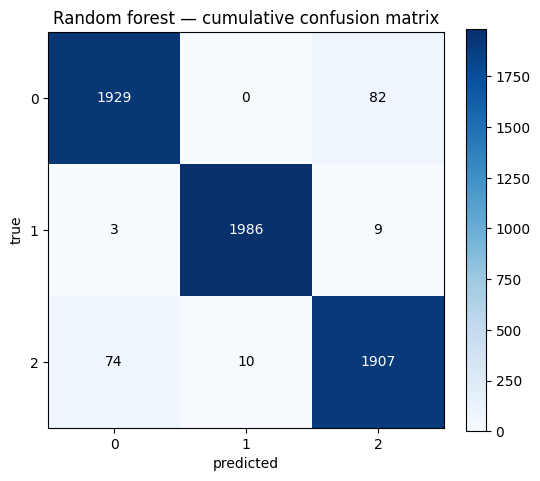

Confusion matrix (rows=true, cols=predicted):
[[1929    0   82]
 [   3 1986    9]
 [  74   10 1907]]


In [18]:
from numcompute_stream import ConfusionMatrix

cm = ConfusionMatrix()
forest_pipe_cm = make_pipeline(
    RandomForestClassifier(n_estimators=12, max_features='sqrt',
                           tree_params=dict(max_depth=10, min_samples_split=60),
                           random_state=0)
)
for Xc, yc in iter_chunks(X, y, chunk_size=CHUNK_SIZE, shuffle=False):
    forest_pipe_cm.partial_fit(Xc, yc, classes=classes)
    if getattr(forest_pipe_cm, 'classes_', None) is not None:
        preds = forest_pipe_cm.predict(Xc)
        cm.update(yc, preds)

class_names = [str(c) for c in meta.get('classes', cm.labels)]
fig = visualise.plot_confusion_matrix(
    cm.result(), labels=class_names,
    title='Random forest — cumulative confusion matrix',
    show=True,
)
plt.show()
print('Confusion matrix (rows=true, cols=predicted):')
print(cm.result())

## 8. Takeaways

* Both models adapt **online**, never seeing the full dataset at once.
* The online **Random Forest** consistently beats the single Hoeffding tree on
  cumulative accuracy